# Importing Essential Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.svm import SVR

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, SequentialFeatureSelector


# Classification

## Loading Dataset for Classification

In [3]:
classification_df = pd.read_csv('../data/breastAltered.csv')

In [4]:
classification_df.head(4)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302.0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517.0,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903.0,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301.0,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300


In [5]:
classification_df.tail(4)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
565,926682.0,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954.0,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241.0,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751.0,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


## Inspection of Dataset for Classification

- Dataset Creator
> The dataset was created by William Wolberg, Olvi Mangasarian, Nick Street, W.Street.

- Dataset Source
> Kaggle Website

In [6]:
classification_df.columns # all the columns in the dataset

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

**Dataset Objective**
> The objective of the dataset is to predict whether a person has breast cancer or not based on the various medical factors like: size of the breast lump, smoothness, radius and other features.

**Dataset Status**
> The dataset contains 32 columns. Each column has different purpose except for one column which is used for the numbering of the dataset training examples.



In [7]:
classification_df.size

18208

In [8]:
classification_df.info(verbose = False)

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Columns: 32 entries, id to fractal_dimension_worst
dtypes: float64(31), str(1)
memory usage: 142.4 KB


## Data Cleaning

### Searching for Missing Values and Duplicate Columns

In [9]:
classification_df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               3
perimeter_mean             0
area_mean                  1
smoothness_mean            3
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  3
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          4
symmetry_se                2
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            5
area_worst                 0
smoothness_worst           2
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             2
fractal_dimension_worst    0
dtype: int64

In [10]:
classification_df.isnull().sum().sum()

np.int64(25)

In [11]:
classification_df.duplicated().sum()

np.int64(0)

**Columns with Missing Values**
- texture_mean
- area_mean
- smoothness_mean
- radius_se
- concave points_se
- symmetry_se
- perimeter_worst
- smoothness_worst
- symmetry_worst

### Cleaning the Numerical Columns Using the Data Imputation Techniques (mean, median)

In [12]:
classification_df.drop(columns = 'id', inplace = True)

In [13]:
classification_df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [14]:
classification_df.select_dtypes(include = np.number).isnull().sum()

radius_mean                0
texture_mean               3
perimeter_mean             0
area_mean                  1
smoothness_mean            3
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  3
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          4
symmetry_se                2
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            5
area_worst                 0
smoothness_worst           2
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             2
fractal_dimension_worst    0
dtype: int64

In [15]:
classification_df[classification_df['texture_mean'].isnull()]

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
102,B,12.180,NaN,77.22,458.7,0.08013,0.04038,0.02383,0.01770,0.1739,...,13.340,32.84,84.58,547.8,0.1123,0.08862,0.11450,0.07431,0.2694,0.06878
358,B,8.878,NaN,56.74,241.0,0.08293,0.07698,0.04721,0.02381,0.1930,...,9.981,17.70,65.27,302.0,0.1015,0.12480,0.09441,0.04762,0.2434,0.07431
451,M,19.590,NaN,127.70,1191.0,0.10320,0.09871,0.16550,0.09063,0.1663,...,21.440,30.96,139.80,1421.0,0.1528,0.18450,0.39770,0.14660,0.2293,0.06091


In [16]:
print("Min Value of texture mean:", classification_df['texture_mean'].min())
print("Max value of texture mean", classification_df['texture_mean'].max())

Min Value of texture mean: 9.71
Max value of texture mean 39.28


In [17]:
classification_df['texture_mean'] = classification_df['texture_mean'].fillna(value = classification_df['texture_mean'].mean())
classification_df['texture_mean'].isnull().sum()

np.int64(0)

In [18]:
classification_df[classification_df['area_mean'].isnull()]

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
30,M,18.63,25.11,124.8,NaN,0.1064,0.1887,0.2319,0.1244,0.2183,...,23.15,34.01,160.5,1670.0,0.1491,0.4257,0.6133,0.1848,0.3444,0.09782


In [19]:
print("Min Value of area mean:", classification_df['area_mean'].min())
print("Max value of area mean", classification_df['area_mean'].max())

Min Value of area mean: 143.5
Max value of area mean 2501.0


In [20]:
classification_df['area_mean'] = classification_df['area_mean'].fillna(value = classification_df['area_mean'].mean())
classification_df['area_mean'].isnull().sum()

np.int64(0)

In [21]:
print(f"smoothness mean => min: {classification_df['smoothness_mean'].min()}, max: {classification_df['smoothness_mean'].max()}")
print(f"radius_se => min: {classification_df['radius_se'].min()}, max: {classification_df['radius_se'].max()}")
print(f"concave points_se => min: {classification_df['concave points_se'].min()}, max: {classification_df['concave points_se'].max()}")
print(f"symmetry => min: {classification_df['symmetry_se'].min()}, max: {classification_df['symmetry_se'].max()}")
print(f"perimeter_worst => min: {classification_df['perimeter_worst'].min()}, max: {classification_df['perimeter_worst'].max()}")
print(f"symmetry_worst => min: {classification_df['symmetry_worst'].min()}, max: {classification_df['symmetry_worst'].max()}")
print(f"symmetry_se => min: {classification_df['symmetry_se'].min()}, max: {classification_df['symmetry_se'].max()}")


smoothness mean => min: 0.05263, max: 0.1634
radius_se => min: 0.1115, max: 2.873
concave points_se => min: 0.0, max: 0.05279
symmetry => min: 0.007882, max: 0.07895
perimeter_worst => min: 50.41, max: 251.2
symmetry_worst => min: 0.1565, max: 0.6638
symmetry_se => min: 0.007882, max: 0.07895


In [22]:
classification_df['smoothness_mean'] = classification_df['smoothness_mean'].fillna(value = classification_df['smoothness_mean'].mean())
classification_df['concave points_se'] = classification_df['concave points_se'].fillna(value = classification_df['concave points_se'].mean())
classification_df['symmetry_worst'] = classification_df['symmetry_worst'].fillna(value = classification_df['symmetry_worst'].mean())

classification_df[['smoothness_mean', 'concave points_se', 'symmetry_worst']].isnull().sum()

smoothness_mean      0
concave points_se    0
symmetry_worst       0
dtype: int64

In [23]:
classification_df['radius_se'] = classification_df['radius_se'].fillna(value = classification_df['radius_se'].mean())
classification_df['symmetry_se'] = classification_df['symmetry_se'].fillna(value = classification_df['symmetry_se'].mean())
classification_df['perimeter_worst'] = classification_df['perimeter_worst'].fillna(value = classification_df['perimeter_worst'].mean())
classification_df['smoothness_worst'] = classification_df['smoothness_worst'].fillna(value = classification_df['smoothness_worst'].mean())

classification_df[['radius_se', 'symmetry_se', 'perimeter_worst', 'smoothness_worst']].isnull().sum()

radius_se           0
symmetry_se         0
perimeter_worst     0
smoothness_worst    0
dtype: int64

In [24]:
classification_df.isnull().sum().sum()

np.int64(0)

### Cleaning Categorical Columns


In [25]:
classification_df.select_dtypes(exclude=np.number).isnull().sum()

#What can be used for filling up categorical missing variables?
# ffill() or bfill()
# mode

diagnosis    0
dtype: int64

## Summary Statistics

#### For Numerical Columns

In [26]:
classification_df.select_dtypes(include = np.number).head(2)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902


In [27]:
Cnumeric_cols = classification_df.select_dtypes(include = np.number)
print("Variance of the Different Columns: \n", Cnumeric_cols.var())

# Variance helps in determining how far each data point is from the mean in the column

Variance of the Different Columns: 
 radius_mean                    12.418920
texture_mean                   18.413386
perimeter_mean                590.440480
area_mean                  123512.717515
smoothness_mean                 0.000197
compactness_mean                0.002789
concavity_mean                  0.006355
concave points_mean             0.001506
symmetry_mean                   0.000752
fractal_dimension_mean          0.000050
radius_se                       0.076835
texture_se                      0.304316
perimeter_se                    4.087896
area_se                      2069.431583
smoothness_se                   0.000009
compactness_se                  0.000321
concavity_se                    0.000911
concave points_se               0.000038
symmetry_se                     0.000068
fractal_dimension_se            0.000007
radius_worst                   23.360224
texture_worst                  37.776483
perimeter_worst              1116.211358
area_worst          

In [28]:
Cnumeric_cols.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.284099,91.969033,654.126585,0.096309,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.174947,880.583128,0.132326,0.254265,0.272188,0.114606,0.290302,0.083946
std,3.524049,4.291082,24.298981,351.443762,0.014032,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.409749,569.356993,0.022771,0.157336,0.208624,0.065732,0.061749,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.180000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.160000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250600,0.071460
50%,13.370000,18.870000,86.240000,551.100000,0.095920,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.820000,686.500000,0.131400,0.211900,0.226700,0.099930,0.282600,0.080040
75%,15.780000,21.780000,104.100000,782.600000,0.105100,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.000000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


#### For Categorical Columns

In [29]:
Ccategorical_cols = classification_df.select_dtypes(exclude = np.number)
Ccategorical_cols

,diagnosis
0,M
1,M
2,M
3,M
4,M
...,...
564,M
565,M
566,M
567,M


In [30]:
Ccategorical_cols['diagnosis'].unique()

<StringArray>
['M', 'B']
Length: 2, dtype: str

In [31]:
Ccategorical_cols['diagnosis'].mode()

0    B
Name: diagnosis, dtype: str

## Data Visualization and Interpretation (Classification)

### Univariate Analysis

##### Histogram (Raduis of the tumor)

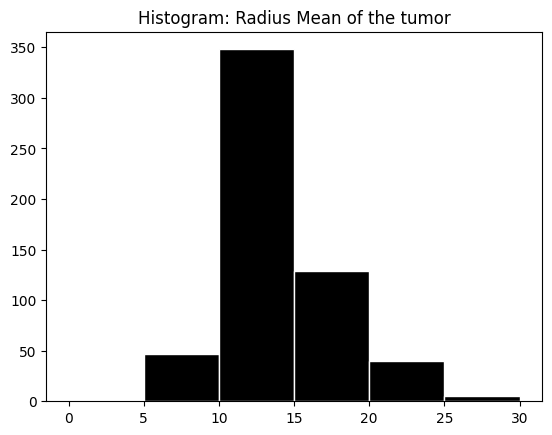

In [32]:
bins = [0, 5, 10, 15, 20, 25, 30]

plt.hist(x = classification_df['radius_mean'], bins = bins, color = "#000", edgecolor = "#fff")

plt.title("Histogram: Radius Mean of the tumor")
plt.show()

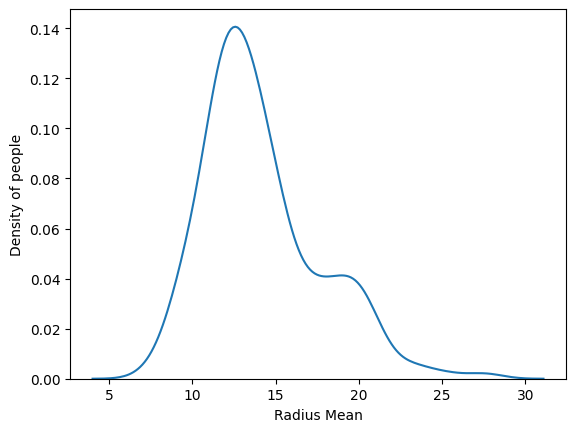

In [33]:
sns.kdeplot(classification_df, x = 'radius_mean')

plt.xlabel("Radius Mean")
plt.ylabel("Density of people")
plt.show()


- Right Skewed Data as the tail of the kde plot is towards right
- Mean > Median > Mode
- Modality Distribution => Unimodal as there's only one peak in the histogram

##### Barplot (Diagnosis - Target Variable)

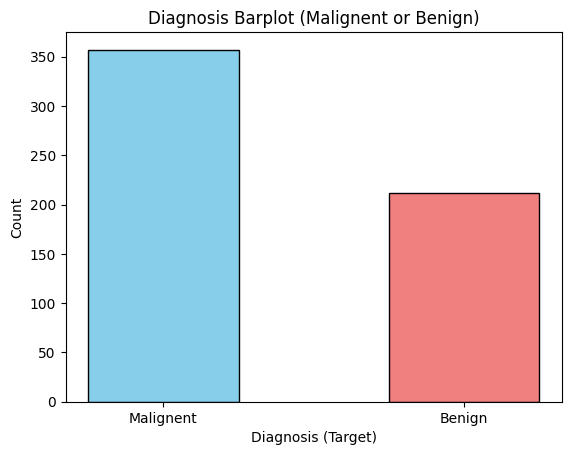

In [34]:
values = []

labels = ["Malignent", "Benign"]

plt.bar(labels, classification_df['diagnosis'].value_counts(), color = ['skyblue', 'lightcoral'], width=0.5, edgecolor = "000")

plt.title("Diagnosis Barplot (Malignent or Benign)")
plt.ylabel("Count")
plt.xlabel("Diagnosis (Target)")
plt.show()


##### Box plot (Radius Worst)

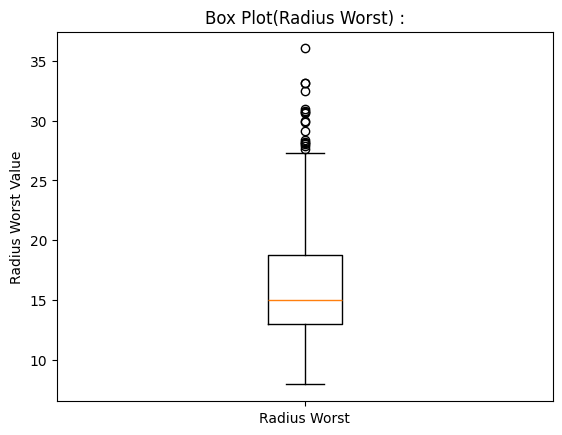

In [35]:
plt.boxplot(classification_df['radius_worst'], tick_labels = ['Radius Worst',])

plt.title("Box Plot(Radius Worst) :")
plt.ylabel("Radius Worst Value")
plt.show()

### Bivariate Analysis

In [36]:
labelEncoder = LabelEncoder()
classification_df['diagnosis'] = labelEncoder.fit_transform(classification_df['diagnosis'])

# Categorical column which is also the target variable of the dataset in changed to numerical 
# column using label encoder which ordinally encodes the categorical column

##### Pairplot

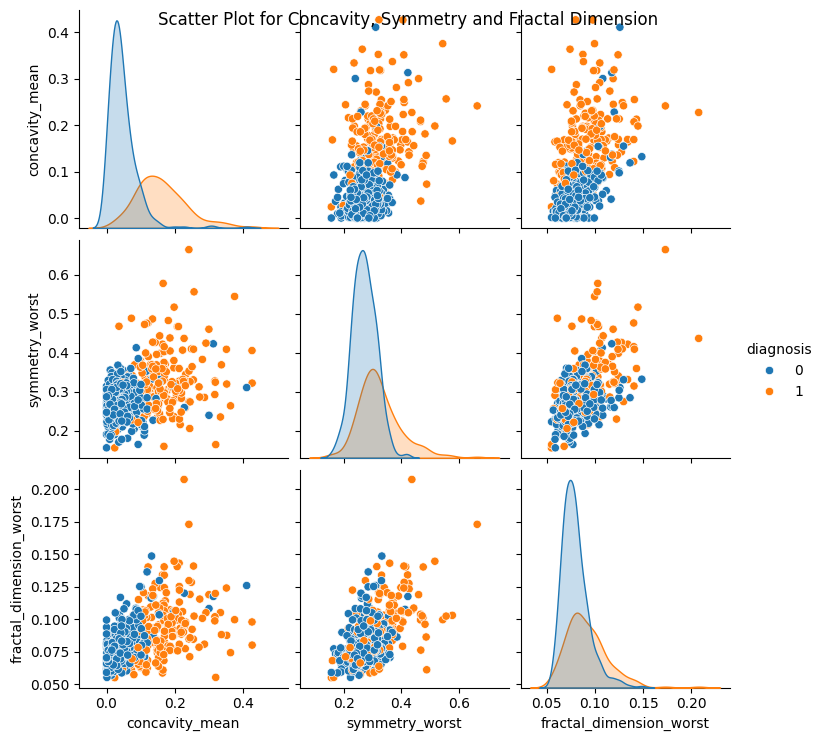

In [37]:
sns.pairplot(classification_df, vars = ['concavity_mean', 'symmetry_worst', 'fractal_dimension_worst'], hue = 'diagnosis')
plt.suptitle('Scatter Plot for Concavity, Symmetry and Fractal Dimension')
plt.show()

##### Scatter Plot

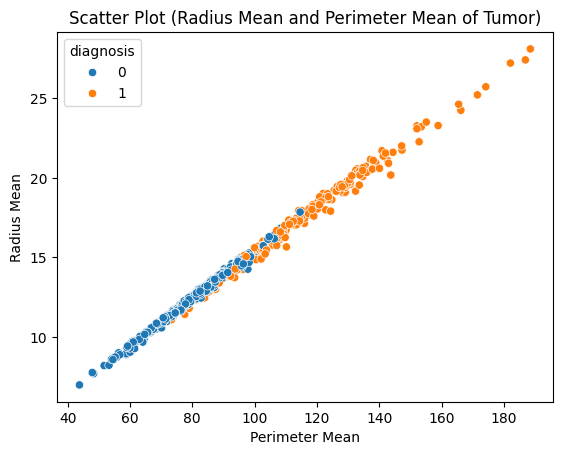

In [38]:
plt.title('Scatter Plot (Radius Mean and Perimeter Mean of Tumor)')

sns.scatterplot(data = classification_df, x = 'perimeter_mean', y = 'radius_mean', hue = 'diagnosis')

plt.xlabel("Perimeter Mean")
plt.ylabel("Radius Mean")

plt.show()

##### Heatmap

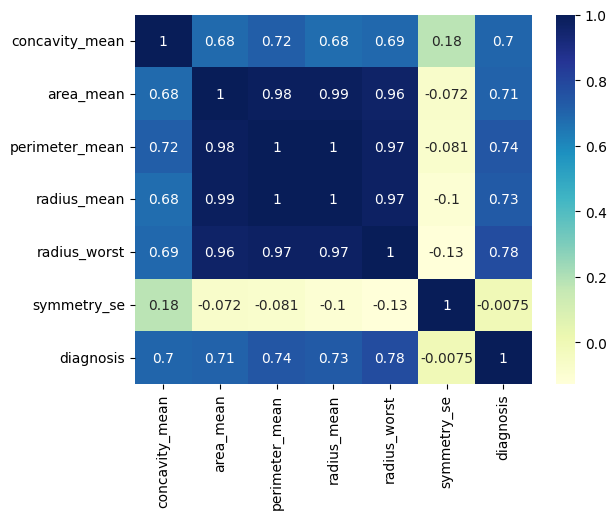

In [39]:
classification_corr = classification_df[['concavity_mean', 'area_mean','perimeter_mean', 'radius_mean', 'radius_worst','symmetry_se','diagnosis']].corr()
sns.heatmap(classification_corr, annot = True, cmap = "YlGnBu")

plt.show()

## Classification Models

### Train Test Split and Scaling

In [40]:
l_x = classification_df.drop(columns = 'diagnosis')
l_y = classification_df['diagnosis']

In [41]:
L_X_train, L_X_test, l_y_train, l_y_test = train_test_split(l_x, l_y, test_size = 0.2)

In [42]:
scaler = StandardScaler()

In [43]:
L_X_train_scaled = scaler.fit_transform(L_X_train)
L_X_test_scaled = scaler.fit_transform(L_X_test)

### **Logistic Regression**

#### Before Using Scaled Data

In [44]:
Logistic_Regresseion_Model = LogisticRegression(max_iter = 1000).fit(L_X_train, l_y_train)

d:\Darshan\Projects\AI_ML\EDA_Classification and Regression Models\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [45]:
l_y_pred_train = Logistic_Regresseion_Model.predict(L_X_train)
l_y_pred_test = Logistic_Regresseion_Model.predict(L_X_test)

In [46]:
Logistic_Regresseion_Model.score(L_X_train, l_y_train)

0.9538461538461539

In [47]:
confusionMatrix = metrics.confusion_matrix(l_y_test, l_y_pred_test)

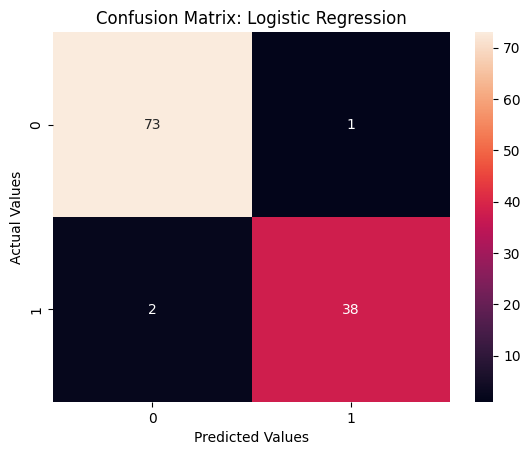

In [48]:
plt.title("Confusion Matrix: Logistic Regression")
sns.heatmap(confusionMatrix, annot = True)
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.show()

In [49]:
print(metrics.classification_report(l_y_test, l_y_pred_test))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        74
           1       0.97      0.95      0.96        40

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



#### After Using Scaled Data

In [50]:
Logistic_Regresseion_Scaled_Model = LogisticRegression(max_iter = 1000).fit(L_X_train_scaled, l_y_train)

In [51]:
l_y_pred_train_scaled = Logistic_Regresseion_Scaled_Model.predict(L_X_train_scaled)
l_y_pred_test_scaled = Logistic_Regresseion_Scaled_Model.predict(L_X_test_scaled)

In [52]:
Logistic_Regresseion_Scaled_Model.score(L_X_train_scaled, l_y_train)

0.9846153846153847

In [53]:
Logistic_Regresseion_Scaled_Model.score(L_X_test_scaled, l_y_test)

0.9912280701754386

In [54]:
confusionMatrixScaled = metrics.confusion_matrix(l_y_test, l_y_pred_test_scaled)

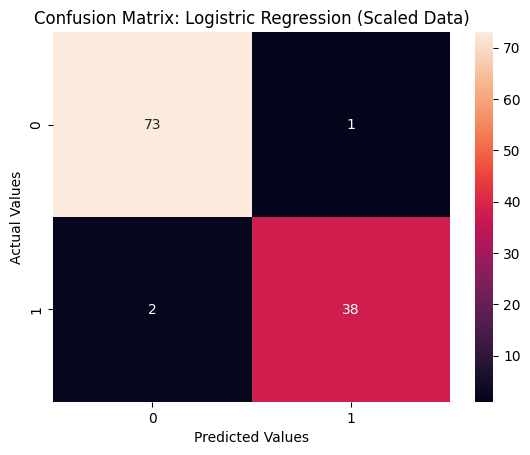

In [55]:
plt.title("Confusion Matrix: Logistric Regression (Scaled Data)")
sns.heatmap(confusionMatrix, annot = True)
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")

plt.show()

In [56]:
print(metrics.classification_report(l_y_test, l_y_pred_test_scaled))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        74
           1       1.00      0.97      0.99        40

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



### **Random Forest Classifier**

#### Before Using Scaled Data

In [57]:
Random_Forest_Model = RandomForestClassifier()
Random_Forest_Model.fit(L_X_train, l_y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [58]:
l_y_pred_train = Random_Forest_Model.predict(L_X_train)
l_y_pred_test = Random_Forest_Model.predict(L_X_test)

In [59]:
Random_Forest_Model.score(L_X_train, l_y_train)

1.0

In [60]:
Random_Forest_Model.score(L_X_test, l_y_test)

0.9824561403508771

In [61]:
confusionMatrix = metrics.confusion_matrix(l_y_test, l_y_pred_test)

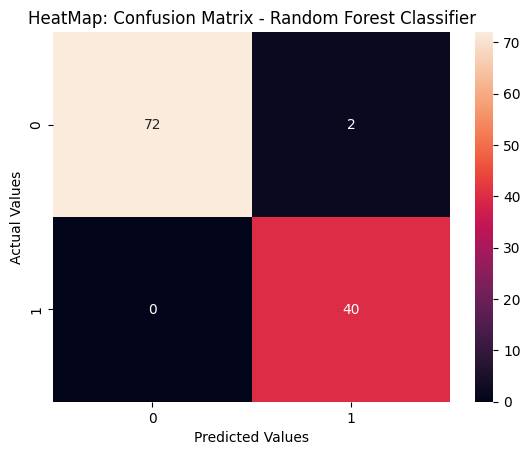

In [62]:
plt.title("HeatMap: Confusion Matrix - Random Forest Classifier")
sns.heatmap(confusionMatrix, annot = True)
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

In [63]:
print(metrics.classification_report(l_y_test, l_y_pred_test))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        74
           1       0.95      1.00      0.98        40

    accuracy                           0.98       114
   macro avg       0.98      0.99      0.98       114
weighted avg       0.98      0.98      0.98       114



#### After Using Scaled Data

In [64]:
Random_Forest_Model = RandomForestClassifier()
Random_Forest_Model.fit(L_X_train_scaled, l_y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [65]:
l_y_pred_train_scaled = Random_Forest_Model.predict(L_X_train_scaled)
l_y_pred_test_scaled = Random_Forest_Model.predict(L_X_test_scaled)

In [66]:
Random_Forest_Model.score(L_X_train_scaled, l_y_train)

1.0

In [67]:
Random_Forest_Model.score(L_X_test_scaled, l_y_test)

0.9912280701754386

In [68]:
confusionMatrix = metrics.confusion_matrix(l_y_test, l_y_pred_test_scaled)

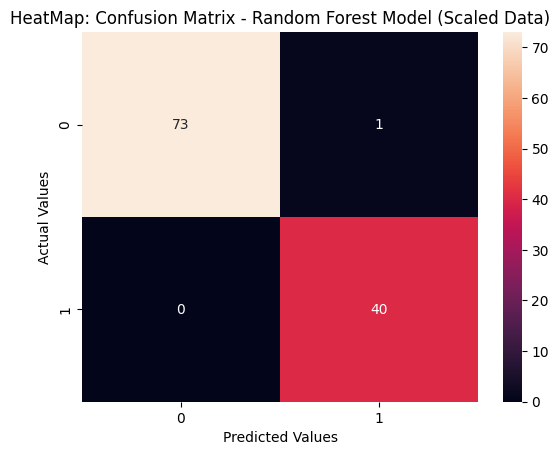

In [69]:
plt.title("HeatMap: Confusion Matrix - Random Forest Model (Scaled Data)")
sns.heatmap(confusionMatrix, annot = True)
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

In [70]:
print(metrics.classification_report(l_y_test, l_y_pred_test_scaled))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99        74
           1       0.98      1.00      0.99        40

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



### **Hyper Parameter Tuning**

#### Logistic Model

In [80]:
logistic_parameters = {'C': [0.2, 0.6, 1], 
                       'fit_intercept': [True, False]}

In [81]:
Logistic_Regression_Model_Tuned = GridSearchCV(LogisticRegression(), logistic_parameters)

In [82]:
classification_df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [83]:
Logistic_Regression_Model_Tuned.fit(L_X_train_scaled, l_y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.2, 0.6, ...], 'fit_intercept': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold

In [85]:
Logistic_Regression_Model_Tuned.best_params_

{'C': 0.2, 'fit_intercept': False}

In [90]:
print("Accuracy of Untuned Model (Training): ", Logistic_Regresseion_Scaled_Model.score(L_X_train_scaled, l_y_train))
print("Accuracy of Tuned Model (Training): ", Logistic_Regression_Model_Tuned.score(L_X_train_scaled, l_y_train))

Accuracy of Untuned Model (Training):  0.9846153846153847
Accuracy of Tuned Model (Training):  0.9846153846153847


In [92]:
print("Accuracy of Untuned Model (Testing): ", Logistic_Regresseion_Scaled_Model.score(L_X_test_scaled, l_y_test))
print("Accuracy of Tuned Model (Testing): ", Logistic_Regression_Model_Tuned.score(L_X_test_scaled, l_y_test))

Accuracy of Untuned Model (Testing):  0.9912280701754386
Accuracy of Tuned Model (Testing):  1.0


In [94]:
l_y_pred_test_tuned = Logistic_Regression_Model_Tuned.predict(L_X_test_scaled)

In [95]:
confusionMatrixTuned = metrics.confusion_matrix(l_y_test, l_y_pred_test_tuned)

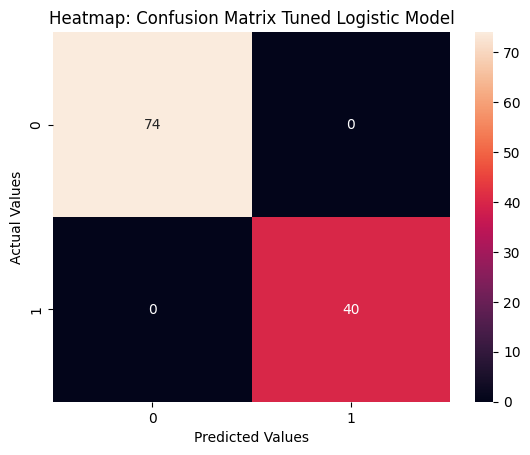

In [96]:
plt.title("Heatmap: Confusion Matrix Tuned Logistic Model")
sns.heatmap(confusionMatrixTuned, annot = True)
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

#### Random Forest

In [97]:
forest_parameters = {'n_estimators': [100, 110, 120], 
                     'max_depth': [9, 10, 11, 12],
                     'max_features': [3, 4, 5, 6],
                     'max_leaf_nodes': [9, 10, 11, 12],
                     'criterion': ['gini', 'entropy', 'log_loss']}

Random_Forest_Model_Tuned = RandomForestClassifier()
Random_Forest_Model_Tuned = GridSearchCV(Random_Forest_Model_Tuned, forest_parameters)

In [98]:
Random_Forest_Model_Tuned.fit(L_X_train_scaled, l_y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [9, 10, ...], 'max_features': [3, 4, ...], 'max_leaf_nodes': [9, 10, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and p

In [99]:
Random_Forest_Model_Tuned.best_params_

{'criterion': 'entropy',
 'max_depth': 9,
 'max_features': 6,
 'max_leaf_nodes': 12,
 'n_estimators': 120}

In [100]:
print("Traning:")
print("Before Hyperparamter Tuning; ", Random_Forest_Model.score(L_X_train_scaled, l_y_train))
print("After Hyperparameter Tuning: ", Random_Forest_Model_Tuned.score(L_X_train_scaled, l_y_train))

Traning:
Before Hyperparamter Tuning;  1.0
After Hyperparameter Tuning:  0.9956043956043956


In [102]:
print("Testing:")
print("Before Hyperparamter Tuning; ", Random_Forest_Model.score(L_X_test_scaled, l_y_test))
print("After Hyperparameter Tuning: ", Random_Forest_Model_Tuned.score(L_X_test_scaled, l_y_test))

Testing:
Before Hyperparamter Tuning;  0.9912280701754386
After Hyperparameter Tuning:  1.0


### **Feature Selection**

#### SelectKBest

In [103]:
k_best_features = SelectKBest(chi2, k = 23)
k_best_features.fit(l_x, l_y)

,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function chi...00205334516F0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",23


In [104]:
k_best_conn = k_best_features.get_support()

In [105]:
l_x_selected_chi = l_x[l_x.columns[k_best_conn]]
l_x_selected_chi.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,radius_se,perimeter_se,...,concave points_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst
0,17.99,10.38,122.80,1001.0,0.27760,0.3001,0.14710,0.2419,1.0950,8.589,...,0.01587,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601
1,20.57,17.77,132.90,1326.0,0.07864,0.0869,0.07017,0.1812,0.5435,3.398,...,0.01340,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750
2,19.69,21.25,130.00,1203.0,0.15990,0.1974,0.12790,0.2069,0.7456,4.585,...,0.02058,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613
3,11.42,20.38,77.58,386.1,0.28390,0.2414,0.10520,0.2597,0.4956,3.445,...,0.01867,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638
4,20.29,14.34,135.10,1297.0,0.13280,0.1980,0.10430,0.1809,0.7572,5.438,...,0.01885,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364


In [106]:
k_best_features = SelectKBest(mutual_info_classif, k = 23)
k_best_features.fit(l_x, l_y)

,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function mut...0020533437110>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",23


In [107]:
k_best_conn = k_best_features.get_support()

In [108]:
l_x_selected_mutual = l_x[l_x.columns[k_best_conn]]
l_x_selected_mutual.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,radius_se,perimeter_se,...,concave points_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,1.0950,8.589,...,0.01587,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.5435,3.398,...,0.01340,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.7456,4.585,...,0.02058,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.4956,3.445,...,0.01867,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.7572,5.438,...,0.01885,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364


#### Checking Accuracy of Model using the selected features from param (score_fun = chi2)

In [114]:
X_train, X_test, y_train, y_test = train_test_split(l_x_selected_chi, l_y, test_size = 0.2)

In [115]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [116]:
Logistic_Model_Check = LogisticRegression(C = 0.2, fit_intercept = False)

In [118]:
Logistic_Model_Check.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.2
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",False
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mu

In [119]:
Logistic_Model_Check.score(X_train_scaled, y_train)

0.989010989010989

In [120]:
Random_Model_Check = RandomForestClassifier(criterion = "entropy", max_depth = 10, max_features = 6, max_leaf_nodes = 11, n_estimators = 110)
Random_Model_Check.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",110
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",6
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",11
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tru

In [121]:
Random_Model_Check.score(X_train, y_train)

0.9956043956043956

In [122]:
Random_Model_Check.score(X_test, y_test)

0.9649122807017544

#### Checking Accuracy of Model using the selected features from param (score_fun = mutual_info_classif)

In [133]:
X_train, X_test, y_train, y_test = train_test_split(l_x_selected_mutual, l_y, test_size = 0.2)

In [134]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [135]:
Logistic_Model_Check = LogisticRegression(C = 1, fit_intercept = False).fit(X_train_scaled, y_train)

In [136]:
Logistic_Model_Check.score(X_train_scaled, y_train)

0.9846153846153847

In [137]:
Logistic_Model_Check.score(X_test_scaled, y_test)

1.0

In [141]:
Random_Model_Check = RandomForestClassifier(criterion = 'entropy', max_depth = 9, max_features = 5, max_leaf_nodes = 9, n_estimators = 110)
Random_Model_Check.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",110
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",9
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",9
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true,

In [142]:
Random_Model_Check.score(X_train_scaled, y_train)

0.989010989010989

In [143]:
Random_Model_Check.score(X_test_scaled, y_test)

0.9824561403508771

### **Final Model**

#### Final Train, Test, Split and Scaling

In [175]:
X_train, X_test, y_train, y_test = train_test_split(l_x_selected_mutual, l_y, test_size = 0.2)

In [176]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Logistic Regression Final Model

In [177]:
Logistic_Regression_Model = LogisticRegression(C = 0.2, fit_intercept = False).fit(X_train, y_train)

In [169]:
Logistic_Regression_Model.score(X_train, y_train)

0.989010989010989

In [178]:
Logistic_Regression_Model.score(X_test, y_test)

0.9824561403508771

In [179]:
y_test_pred = Logistic_Regression_Model.predict(X_test)

In [180]:
confusionMatrix = metrics.confusion_matrix(y_test, y_test_pred)

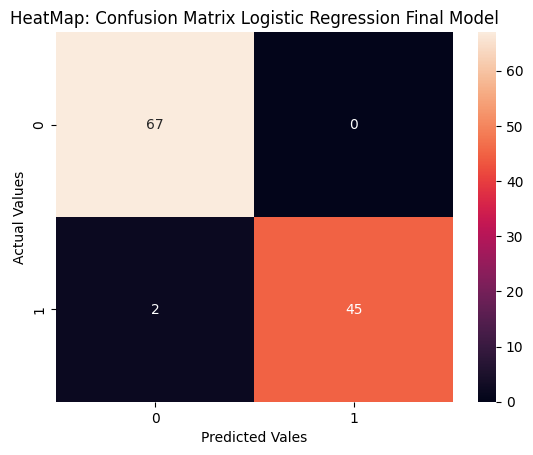

In [182]:
plt.title("HeatMap: Confusion Matrix Logistic Regression Final Model")
sns.heatmap(confusionMatrix, annot = True)
plt.xlabel("Predicted Vales")
plt.ylabel("Actual Values")
plt.show()

In [183]:
print(metrics.classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        67
           1       1.00      0.96      0.98        47

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



#### Random Forest Final Model

In [184]:
Random_Forest_Model = RandomForestClassifier(criterion = 'entropy', n_estimators = 110, max_depth = 9, max_features = 5, max_leaf_nodes = 9)
Random_Forest_Model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",110
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",9
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",9
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true,

In [185]:
Random_Forest_Model.score(X_train, y_train)

0.989010989010989

In [186]:
Random_Forest_Model.score(X_test, y_test)

0.9649122807017544

In [187]:
y_test_pred = Random_Forest_Model.predict(X_test)

In [188]:
confusionMatrix = metrics.confusion_matrix(y_test, y_test_pred)

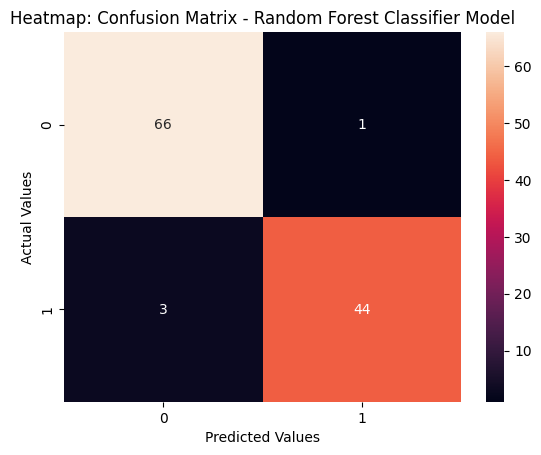

In [189]:
plt.title("Heatmap: Confusion Matrix - Random Forest Classifier Model")
sns.heatmap(confusionMatrix, annot = True)
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.show()

In [190]:
print(metrics.classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        67
           1       0.98      0.94      0.96        47

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# Regression

## Loading Dataset for Regression

In [2]:
regression_df = pd.read_csv('../data/diamonds1.csv')
regression_df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Inspection of Dataset for Regression

> - The dataset was created by Shivam Agrawal who is an Application Developer at IBM

> - Data was accessed through Kaggle platform

> - Objective of the dataset is to predict the price of diamond using different features like carat, cut, color, depth and so on.

In [3]:
regression_df.size

539400

In [4]:
regression_df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='str')

In [5]:
regression_df.info(verbose = False)

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Columns: 10 entries, carat to z
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


## Data Cleaning

### Searching for Missing Values

In [6]:
regression_df.isnull().sum()

carat      0
cut        0
color      3
clarity    5
depth      0
table      0
price      0
x          5
y          5
z          2
dtype: int64

In [7]:
regression_df.isnull().sum().sum()

np.int64(20)

In [8]:
regression_df.duplicated().sum()

np.int64(146)

### Cleaning the Numerical Columns using Data imputation Techniques - Mean and Median

In [9]:
regression_df.select_dtypes(include = np.number).isnull().sum()

carat    0
depth    0
table    0
price    0
x        5
y        5
z        2
dtype: int64

In [10]:
print(f"Column 'x' Min Value => {regression_df['x'].min()}, Max Value => {regression_df['x'].max()}")
print(f"Column 'y' Min Value => {regression_df['y'].min()}, Max Value => {regression_df['y'].max()}")
print(f"Column 'z' Min Value => {regression_df['z'].min()}, Max Value => {regression_df['z'].max()}")

Column 'x' Min Value => 0.0, Max Value => 10.74
Column 'y' Min Value => 0.0, Max Value => 58.9
Column 'z' Min Value => 0.0, Max Value => 31.8


In [11]:
regression_df['x'] = regression_df['x'].fillna(regression_df['x'].mean()) 
regression_df['x'].isnull().sum()

np.int64(0)

In [12]:
regression_df['y'] = regression_df['y'].fillna(regression_df['y'].median())
regression_df['y'].isnull().sum()

np.int64(0)

In [13]:
regression_df['z'] = regression_df['z'].fillna(regression_df['z'].median())
regression_df['z'].isnull().sum()

np.int64(0)

### Cleaning the Categorical Columns using the data Imputation Method (Mode)

In [14]:
regression_df.select_dtypes(exclude = np.number).isnull().sum()

cut        0
color      3
clarity    5
dtype: int64

In [15]:
regression_df['color'] = regression_df['color'].fillna(regression_df['color'].mode()[0])
regression_df['color'].isnull().sum()

np.int64(0)

In [16]:
regression_df['clarity'] = regression_df['clarity'].ffill()

In [17]:
regression_df['clarity'].isnull().sum()

np.int64(0)

In [18]:
regression_df.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

## Summary Statistics

### For Numerical Columns

In [19]:
regression_df.select_dtypes(include = np.number).head()

,carat,depth,table,price,x,y,z
0,0.23,61.5,55.0,326,3.95,3.98,2.43
1,0.21,59.8,61.0,326,3.89,3.84,2.31
2,0.23,56.9,65.0,327,4.05,4.07,2.31
3,0.29,62.4,58.0,334,4.20,4.23,2.63
4,0.31,63.3,58.0,335,4.34,4.35,2.75


In [20]:
Rnumerical_cols = regression_df.select_dtypes(include = np.number)
print("Variance: \n", Rnumerical_cols.var())

Variance: 
 carat    2.246867e-01
depth    2.052404e+00
table    4.992948e+00
price    1.591563e+07
x        1.258317e+00
y        1.304306e+00
z        4.980071e-01
dtype: float64


In [21]:
Rnumerical_cols.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731166,5.734557,3.538742
std,0.474011,1.432621,2.234491,3989.439738,1.121747,1.142062,0.705696
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


### For Categorical Columns

In [22]:
Rcategorical_cols = regression_df.select_dtypes(exclude = np.number)
Rcategorical_cols.columns

Index(['cut', 'color', 'clarity'], dtype='str')

In [23]:
print(Rcategorical_cols['cut'].unique())
print(Rcategorical_cols['color'].unique())
print(Rcategorical_cols['clarity'].unique())

<StringArray>
['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Length: 5, dtype: str
<StringArray>
['E', 'I', 'J', 'H', 'F', 'G', 'D']
Length: 7, dtype: str
<StringArray>
['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Length: 8, dtype: str


In [24]:
Rcategorical_cols.mode()

,cut,color,clarity
0,Ideal,G,SI1


## Data Visualization and Interpretation (Regression)

### Univariate Analysis

#### Histogram (Diamond Price)

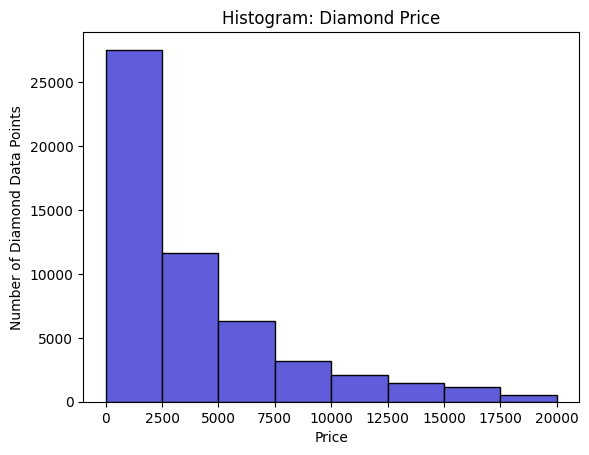

In [25]:
bins = [0, 2500, 5000, 7500, 10000, 12500, 15000, 17500, 20000]

plt.title("Histogram: Diamond Price")
plt.xlabel("Price")
plt.ylabel("Number of Diamond Data Points")
plt.hist(regression_df['price'], bins = bins, color = "#5f5dd9", edgecolor = "#000")
plt.xticks(bins)
plt.show()

#### Box-Plot (Carat)

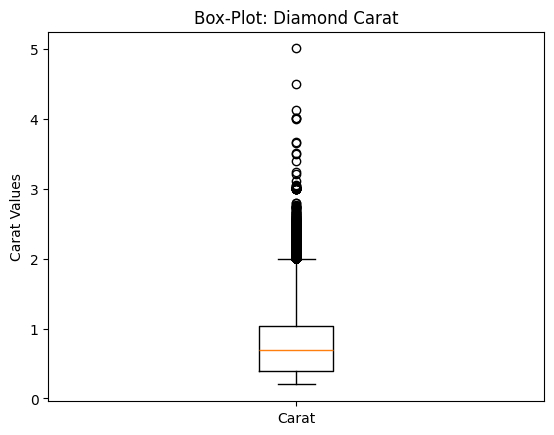

In [26]:
plt.title("Box-Plot: Diamond Carat")

plt.ylabel('Carat Values')
plt.boxplot(regression_df['carat'], tick_labels = ['Carat'])

plt.show()

#### Barplot (Cut Quality of Diamonds)

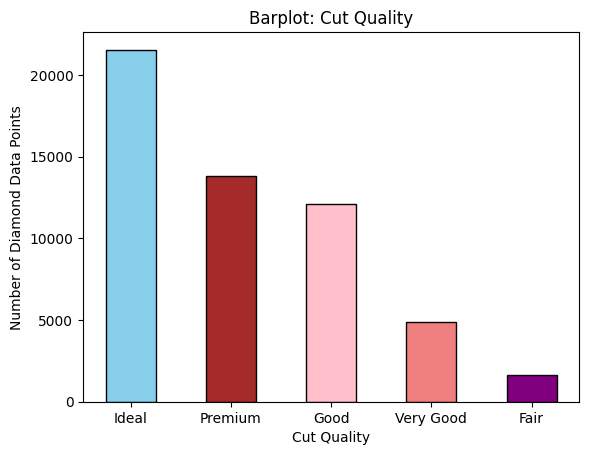

In [27]:
labels = regression_df['cut'].unique()
values_counts = regression_df['cut'].value_counts()
values = [i for i in  values_counts]

plt.title("Barplot: Cut Quality")
plt.xlabel("Cut Quality")
plt.ylabel("Number of Diamond Data Points")
plt.bar(labels, values, width = 0.5, edgecolor = "#000", color = ['skyblue', 'brown', 'pink', 'lightcoral', 'purple'])

plt.show()

### Bivariate Analysis

#### Heatmap (Correlation Between Features)

In [28]:
regression_correlation = regression_df.select_dtypes(include = np.number).corr()

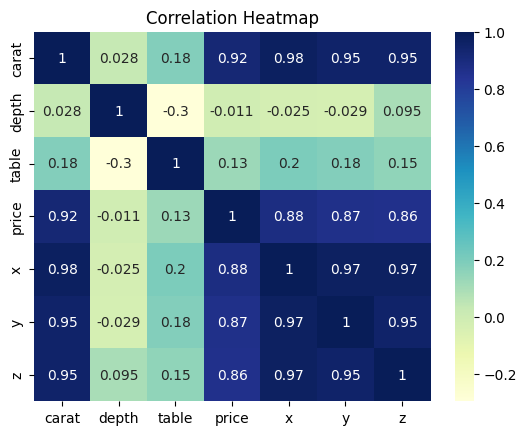

In [29]:
plt.title("Correlation Heatmap")

sns.heatmap(regression_correlation, annot = True, cmap = "YlGnBu")

plt.show()

In [30]:
regression_df.head(1)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43


In [31]:
labelEncoder = LabelEncoder()
regression_df["color"] = labelEncoder.fit_transform(regression_df['color'])
regression_df["cut"] = labelEncoder.fit_transform(regression_df['cut'])
regression_df["clarity"] = labelEncoder.fit_transform(regression_df['clarity'])

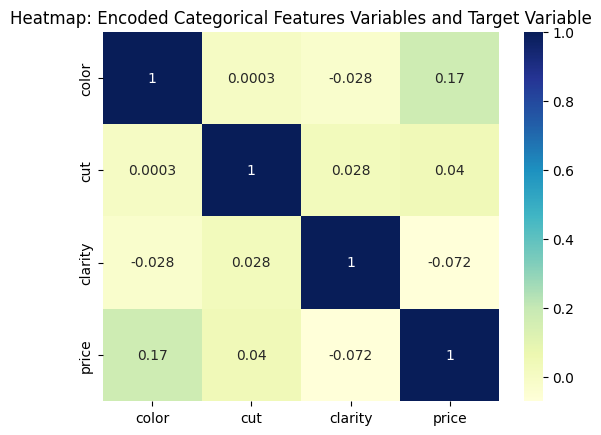

In [32]:
plt.title("Heatmap: Encoded Categorical Features Variables and Target Variable")
sns.heatmap(regression_df[['color', 'cut', 'clarity', 'price']].corr(), annot = True, cmap = "YlGnBu")
plt.show()

#### Scatter Plot

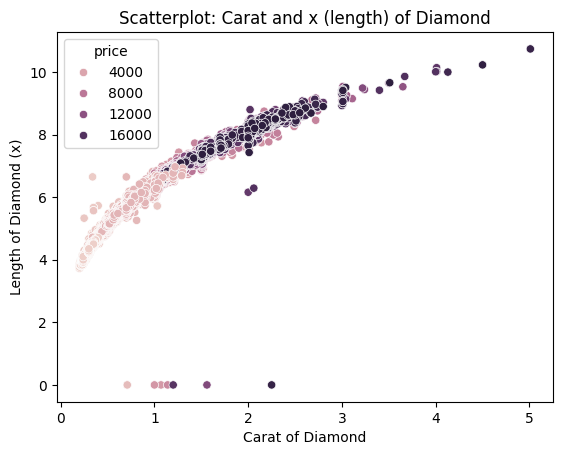

In [33]:
plt.title("Scatterplot: Carat and x (length) of Diamond")

sns.scatterplot(data = regression_df, x = 'carat', y = 'x', hue = 'price')
plt.ylabel("Length of Diamond (x)")
plt.xlabel("Carat of Diamond")

plt.show()

#### Pairplot Plot

<Figure size 640x480 with 0 Axes>

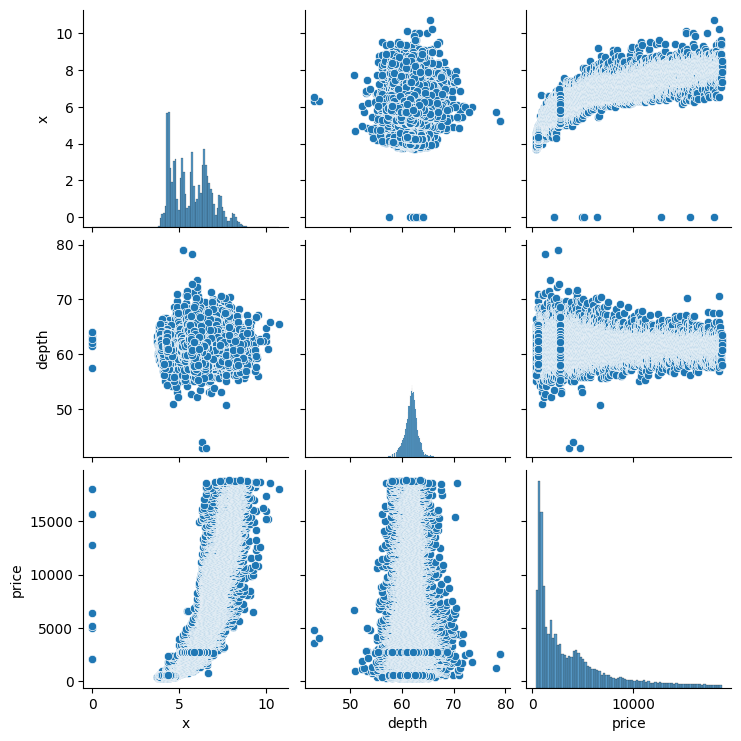

In [34]:
plt.suptitle("Pairplot: x, Depth Percentage and Price of Diamonds", y = 1.02)

sns.pairplot(data = regression_df, vars = ['x', 'depth', 'price'])

plt.show()

## **Regression Models**

### Train Test Split

In [35]:
r_x = regression_df.drop(columns = 'price')
r_y = regression_df['price']

In [36]:
R_X_train, R_X_test, r_y_train, r_y_test = train_test_split(r_x, r_y, test_size = 0.2)

### Linear Regression

In [145]:
Linear_Regression_Model = LinearRegression()

In [146]:
Linear_Regression_Model.fit(R_X_train, r_y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [147]:
r_y_pred_train = Linear_Regression_Model.predict(R_X_train)

In [149]:
r_y_pred_test = Linear_Regression_Model.predict(R_X_test)

In [151]:
print("MAE (Mean Absolute Error) in Training Data: ", mean_absolute_error(r_y_train, r_y_pred_train))
print("MAE (Mean Absolute Error) in Testing Data: ", mean_absolute_error(r_y_test, r_y_pred_test))

MAE (Mean Absolute Error) in Training Data:  869.1431447109054
MAE (Mean Absolute Error) in Testing Data:  844.5214575027159


In [152]:
print("R2 Score in Training Data: ", r2_score(r_y_train, r_y_pred_train))
print("R2 Score in Testing Data: ", r2_score(r_y_test, r_y_pred_test))

R2 Score in Training Data:  0.8834383679545461
R2 Score in Testing Data:  0.8915219445467552


### Support Vector Machine (Regression)

In [153]:
SupportVR_Model = SVR().fit(R_X_train, r_y_train)

In [154]:
r_y_pred_train = SupportVR_Model.predict(R_X_train)

In [155]:
r_y_pred_test = SupportVR_Model.predict(R_X_test)

In [157]:
print(f"MAE (Mean Absolute Error) in Training Data: {mean_absolute_error(r_y_train, r_y_pred_train)}")
print(f"MAE (Mean Absolute Error) in Testing Data: {mean_absolute_error(r_y_test, r_y_pred_test)}")

MAE (Mean Absolute Error) in Training Data: 2765.672432180785
MAE (Mean Absolute Error) in Testing Data: 2763.0307952248486


In [158]:
print(f"MSE (Mean Squared Error) in Training Data: {mean_absolute_error(r_y_train, r_y_pred_train)}")
print(f"MSE (Mean Squared Error) in Testing Data: {mean_absolute_error(r_y_test, r_y_pred_test)}")

MSE (Mean Squared Error) in Training Data: 2765.672432180785
MSE (Mean Squared Error) in Testing Data: 2763.0307952248486


In [ ]:
print(f"R2 Score in Training Data: {r2_score(r_y_train, r_y_pred_train)}")
print(f"R2 Score in Testing Data: {r2_score(r_y_test, r_y_pred_test)}")

R2 Score in Training Data: -0.1245900494826766
R2 Score in Testing Data: -0.12355055237797496


### Hyperparameter Tuning

#### Linear Regression Model

In [161]:
linear_parameters = {'fit_intercept': [True, False],
                     'copy_X': [True, False],
                     'positive': [True, False]}

In [162]:
Linear_Regression_Model_Tuned = GridSearchCV(LinearRegression(), linear_parameters)

In [163]:
Linear_Regression_Model_Tuned.fit(R_X_train, r_y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'copy_X': [True, False], 'fit_intercept': [True, False], 'positive': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is al

In [164]:
Linear_Regression_Model_Tuned.best_params_

{'copy_X': True, 'fit_intercept': True, 'positive': False}

In [165]:
r_y_pred_train = Linear_Regression_Model_Tuned.predict(R_X_train)
r_y_pred_test = Linear_Regression_Model_Tuned.predict(R_X_test)

In [ ]:
print(f"MAE (Training Data): {mean_absolute_error(r_y_train, r_y_pred_train)}")
print(f"MAE (Testing Data): {mean_absolute_error(r_y_test, r_y_pred_test)}")

MAE (Training Data): 869.1431447109054
MAE (Testing Data): 844.5214575027159


In [167]:
print(f"MSE (Training Data): {mean_squared_error(r_y_train, r_y_pred_train)}")
print(f"MSE (Testing Data): {mean_squared_error(r_y_test, r_y_pred_test)}")

MSE (Training Data): 1856802.6493797146
MSE (Testing Data): 1720186.9011969503


In [168]:
print(f"R2 Score (Training Data): {r2_score(r_y_train, r_y_pred_train)}")
print(f"R2 Score (Testing Data): {r2_score(r_y_test, r_y_pred_test)}")

R2 Score (Training Data): 0.8834383679545461
R2 Score (Testing Data): 0.8915219445467552


#### Support Vector Machine (Regression)

In [176]:
support_parameters = {'C': [0.1, 1], 
                      'kernel': ['rbf', 'linear']}

SupportVR_Model_Tuned = GridSearchCV(SVR(), support_parameters, n_jobs = -1, verbose = 2, cv = 3)

In [177]:
SupportVR_Model_Tuned.fit(R_X_train, r_y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1], 'kernel': ['rbf', 'linear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter index

In [178]:
SupportVR_Model_Tuned.best_params_

{'C': 1, 'kernel': 'linear'}

In [179]:
r_y_pred_train = SupportVR_Model_Tuned.predict(R_X_train)
r_y_pred_test = SupportVR_Model_Tuned.predict(R_X_test)

In [180]:
print(f"MAE (Training Data): {mean_absolute_error(r_y_train, r_y_pred_train)}")
print(f"MAE (Testing Data): {mean_absolute_error(r_y_test, r_y_pred_test)}")

MAE (Training Data): 1074.240426242405
MAE (Testing Data): 1059.3719362281417


In [182]:
print(f"MSE (Training Data): {mean_squared_error(r_y_train, r_y_pred_train)}")
print(f"MSE (Testing Data): {mean_squared_error(r_y_test, r_y_pred_test)}")

MSE (Training Data): 3464988.8355713
MSE (Testing Data): 3330193.7962258277


In [183]:
print(f"R2 Score (Training Data): {r2_score(r_y_train, r_y_pred_train)}")
print(f"R2 Score (Testing Data): {r2_score(r_y_test, r_y_pred_test)}")

R2 Score (Training Data): 0.7824837476247734
R2 Score (Testing Data): 0.7899920368852548


### Feature Scaling

In [37]:
scaler = StandardScaler()

In [38]:
R_X_train_scaled = scaler.fit_transform(R_X_train)
R_X_test_scaled = scaler.transform(R_X_test)

In [39]:
Linear_Regression_Model_Tuned_Scaled = LinearRegression(copy_X = True, fit_intercept = True, positive = False)
Linear_Regression_Model_Tuned_Scaled.fit(R_X_train_scaled, r_y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
r_y_pred_train = Linear_Regression_Model_Tuned_Scaled.predict(R_X_train_scaled)
r_y_pred_test = Linear_Regression_Model_Tuned_Scaled.predict(R_X_test_scaled)

In [41]:
print(f"MAE (Training Data): {mean_absolute_error(r_y_train, r_y_pred_train)}")
print(f"MAE (Testing Data): {mean_absolute_error(r_y_test, r_y_pred_test)}")

MAE (Training Data): 864.3865233893164
MAE (Testing Data): 856.5276522761343


In [42]:
print(f"MSE (Training Data): {mean_squared_error(r_y_train, r_y_pred_train)}")
print(f"MSE (Testing Data): {mean_squared_error(r_y_test, r_y_pred_test)}")

MSE (Training Data): 1840951.5099060028
MSE (Testing Data): 1783358.798770833


In [43]:
print(f"R2 (Training Data): {r2_score(r_y_train, r_y_pred_train)}")
print(f"R2 (Testing Data): {r2_score(r_y_test, r_y_pred_test)}")

R2 (Training Data): 0.8840465863699578
R2 (Testing Data): 0.8890254666426795


### Feature Selection

#### Sequential Feature Selection (Wrapper Method)

In [44]:
Linear_Regression_Model_Tuned = LinearRegression(copy_X = True, fit_intercept = True, positive = False, n_jobs = None)

In [45]:
sequential_featureSelector = SequentialFeatureSelector(Linear_Regression_Model_Tuned, n_features_to_select = 5, direction = 'forward')

In [46]:
sequential_featureSelector.fit(r_x, r_y)

,estimator estimator: estimator instanceAn unfitted estimator.,LinearRegression()
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",5
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [48]:
sequential_conn = sequential_featureSelector.get_support()

In [50]:
r_x_selected_features_forward = r_x[r_x.columns[sequential_conn]]
r_x_selected_features_forward.head(3)

,carat,depth,x,y,z
0,0.23,61.5,3.95,3.98,2.43
1,0.21,59.8,3.89,3.84,2.31
2,0.23,56.9,4.05,4.07,2.31


In [51]:
sequential_featureSelector = SequentialFeatureSelector(Linear_Regression_Model_Tuned, n_features_to_select = 5, direction = 'backward')

In [52]:
sequential_featureSelector.fit(r_x, r_y)

,estimator estimator: estimator instanceAn unfitted estimator.,LinearRegression()
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",5
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'backward'
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [53]:
r_x_selected_features_backward = r_x[r_x.columns[sequential_conn]]
r_x_selected_features_backward.head()

,carat,depth,x,y,z
0,0.23,61.5,3.95,3.98,2.43
1,0.21,59.8,3.89,3.84,2.31
2,0.23,56.9,4.05,4.07,2.31
3,0.29,62.4,4.20,4.23,2.63
4,0.31,63.3,4.34,4.35,2.75


#### Checking Accuracy of Sequential Forward Selection

In [55]:
X_train, X_test, y_train, y_test = train_test_split(r_x_selected_features_forward, r_y, test_size = 0.2)

In [56]:
Linear_Regression_Model = LinearRegression(copy_X = True, fit_intercept = True, n_jobs = None, positive = False)

In [57]:
Linear_Regression_Model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [58]:
y_train_pred = Linear_Regression_Model.predict(X_train)
y_test_pred = Linear_Regression_Model.predict(X_test)

In [59]:
print(f"MAE (Training Data): {mean_absolute_error(y_train, y_train_pred)}")
print(f"MAE (Testing Data): {mean_absolute_error(y_test, y_test_pred)}")

MAE (Training Data): 899.5768894722909
MAE (Testing Data): 891.3455014796772


In [60]:
print(f"MSE (Training Data): {mean_squared_error(y_train, y_train_pred)}")
print(f"MSE (Testing Data): {mean_squared_error(y_test, y_test_pred)}")

MSE (Training Data): 2308731.0877451072
MSE (Testing Data): 2226796.5120915566


In [62]:
print(f"R2 Score (Training Data): {r2_score(y_train, y_train_pred)}")
print(f"R2 Score (Testing Data): {r2_score(y_test, y_test_pred)}")

R2 Score (Training Data): 0.8557341826317155
R2 Score (Testing Data): 0.8569010088716127


In [63]:
SupportVR_Model = SVR(C = 1, kernel = 'linear')
SupportVR_Model.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [64]:
y_train_pred = SupportVR_Model.predict(X_train)
y_test_pred = SupportVR_Model.predict(X_test)

In [65]:
print(f"MAE (Training Data): {mean_absolute_error(y_train, y_train_pred)}")
print(f"MAE (Testing Data): {mean_absolute_error(y_test, y_test_pred)}")

MAE (Training Data): 1130.6209281547688
MAE (Testing Data): 1112.3355136213204


In [66]:
print(f"MSE (Training Data): {mean_squared_error(y_train, y_train_pred)}")
print(f"MSE (Testing Data): {mean_squared_error(y_test, y_test_pred)}")

MSE (Training Data): 3912508.052913487
MSE (Testing Data): 3772851.1079641744


In [67]:
print(f"R2 Score (Training Data): {r2_score(y_train, y_train_pred)}")
print(f"R2 Score (Testing Data): {r2_score(y_test, y_test_pred)}")

R2 Score (Training Data): 0.7555188756240822
R2 Score (Testing Data): 0.7575480362504298


#### Checking Accuracy of Sequential Backward Selection

In [68]:
X_train, X_test, y_train, y_test = train_test_split(r_x_selected_features_backward, r_y, test_size = 0.2)

In [69]:
Linear_Regression_Model = LinearRegression(copy_X = True, fit_intercept = True, positive = False, n_jobs = None)

In [70]:
Linear_Regression_Model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [71]:
y_train_pred = Linear_Regression_Model.predict(X_train)
y_test_pred = Linear_Regression_Model.predict(X_test)

In [72]:
print(r2_score(y_train, y_train_pred))
print(r2_score(y_test, y_test_pred))

0.8580472349956951
0.8493994473469676


In [73]:
SupportVR_Model = SVR(C = 1, kernel = 'linear')
SupportVR_Model.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [74]:
y_train_pred = SupportVR_Model.predict(X_train)
y_test_pred = SupportVR_Model.predict(X_test)

In [75]:
print(r2_score(y_train, y_train_pred))
print(r2_score(y_test, y_test_pred))

0.7549367418732588
0.7545477420088738


### Final Models

#### Train Test Split Final

In [76]:
X_train, X_test, y_train, y_test = train_test_split(r_x_selected_features_backward, r_y, test_size = 0.2)

#### Linear Regression Final Model

In [77]:
Linear_Regression_Model = LinearRegression(copy_X=True, fit_intercept = True, n_jobs = None, positive = False, )

In [78]:
Linear_Regression_Model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [79]:
y_train_pred = Linear_Regression_Model.predict(X_train)
y_test_pred = Linear_Regression_Model.predict(X_test)

In [81]:
print(f"MAE (Training Data): {mean_absolute_error(y_train, y_train_pred)}")
print(f"MAE (Testing Data): {mean_absolute_error(y_test, y_test_pred)}")

MAE (Training Data): 896.7005385122554
MAE (Testing Data): 908.6582355138987


In [82]:
print(f"MSE (Training Data): {mean_squared_error(y_train, y_train_pred)}")
print(f"MSE (Testing Data): {mean_squared_error(y_test, y_test_pred)}")

MSE (Training Data): 2274857.21944635
MSE (Testing Data): 2368533.00332192


In [83]:
print(f"R2 Score (Training Data): {r2_score(y_train, y_train_pred)}")
print(f"R2 Score (Test Data): {r2_score(y_test, y_test_pred)}")

R2 Score (Training Data): 0.8560890401790844
R2 Score (Test Data): 0.8551044467327407


#### Support Vector Machine Final Model

In [84]:
SupportVR_Model = SVR(C = 1, kernel = 'linear')

In [85]:
SupportVR_Model.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [86]:
y_train_pred = SupportVR_Model.predict(X_train)
y_test_pred = SupportVR_Model.predict(X_test)

In [87]:
print(f"MAE (Training Data): {mean_absolute_error(y_train, y_train_pred)}")
print(f"MAE (Testing Data): {mean_absolute_error(y_test, y_test_pred)}")

MAE (Training Data): 1123.1843411891325
MAE (Testing Data): 1143.6642297541184


In [88]:
print(f"MSE (Training Data): {mean_squared_error(y_train, y_train_pred)}")
print(f"MSE (Testing Data): {mean_squared_error(y_test, y_test_pred)}")

MSE (Training Data): 3854371.4365049894
MSE (Testing Data): 4135062.446157281


In [89]:
print(f"R2 Score (Training Data): {r2_score(y_train, y_train_pred)}")
print(f"R2 Score (Test Data): {r2_score(y_test, y_test_pred)}")

R2 Score (Training Data): 0.7561665461058023
R2 Score (Test Data): 0.7470366002541229
